自变量和因变量近似线性相关：选线性核
否则，绝大多数情况下优先选择高斯核

Fitting 5 folds for each of 88 candidates, totalling 440 fits
最优参数组合：
{'svr__C': 100, 'svr__epsilon': 0.05, 'svr__gamma': 0.5, 'svr__kernel': 'rbf'}

5折交叉验证最优负MSE: -0.0404
------------------------------------------------------------
训练集 MSE: 0.0378
训练集 R²:  0.9319
测试集 MSE: 0.0176
测试集 R²:  0.9704
支持向量总数：101


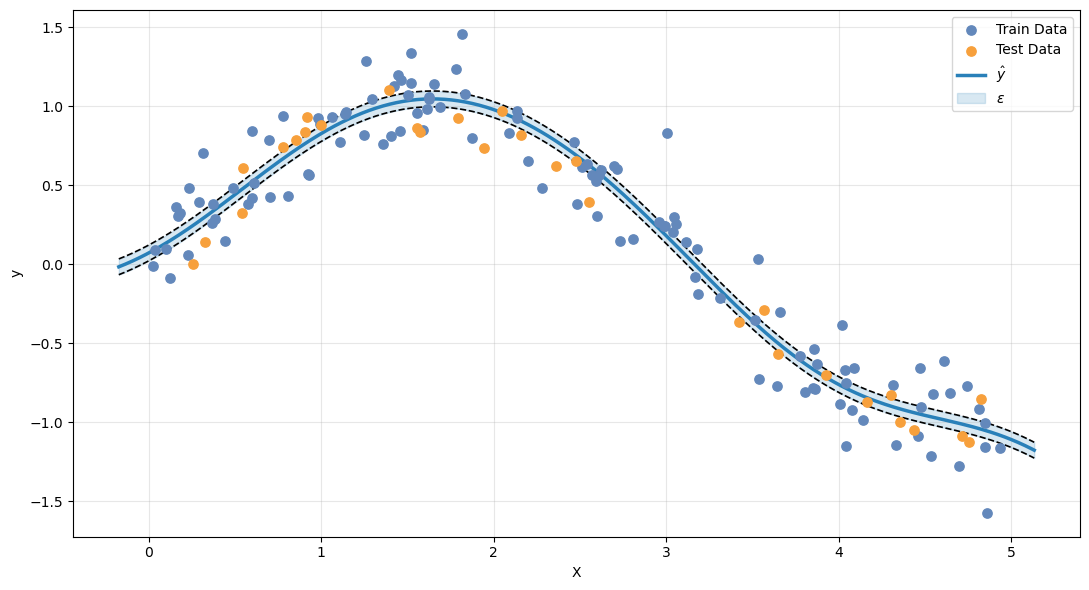

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ===================== 生成非线性数据 =====================
np.random.seed(42)
X = np.sort(5 * np.random.rand(150, 1), axis=0)
y = np.sin(X.ravel()) + np.random.normal(loc=0, scale=0.18, size=X.shape[0])

# 划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 绘图稠密网格
X_smooth = np.linspace(X.min()-0.2, X.max()+0.2, 400).reshape(-1, 1)

# ===================== 网格搜索参数空间 =====================
pipe = make_pipeline(StandardScaler(), SVR())

# 同时遍历不同核函数与超参
param_grid = [
    # 线性核
    {
        "svr__kernel": ["linear"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__epsilon": [0.05, 0.1, 0.2]
    },
    # 多项式核
    {
        "svr__kernel": ["poly"],
        "svr__C": [1, 10],
        "svr__degree": [2, 3],
        "svr__coef0": [0, 1],
        "svr__epsilon": [0.05, 0.1]
    },
    # RBF高斯核（重点搜索）
    {
        "svr__kernel": ["rbf"],
        "svr__C": [0.1, 1, 10, 100],
        "svr__gamma": [0.01, 0.1, 0.5, 1, 2],
        "svr__epsilon": [0.05, 0.1, 0.2]
    }
]

# ===================== 网格搜索 + 5折交叉验证 =====================
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                # 5折交叉验证
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# 获取最优模型
best_model = grid_search.best_estimator_
svr = best_model[-1]

# ===================== 4. 评估模型 =====================
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("="*60)
print("最优参数组合：")
print(grid_search.best_params_)
print(f"\n5折交叉验证最优负MSE: {grid_search.best_score_:.4f}")
print("-"*60)
print(f"训练集 MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"训练集 R²:  {r2_score(y_train, y_train_pred):.4f}")
print(f"测试集 MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
print(f"测试集 R²:  {r2_score(y_test, y_test_pred):.4f}")
print(f"支持向量总数：{len(svr.support_)}")
print("="*60)

# ===================== 5. 可视化最优SVR结果 =====================
y_smooth_pred = best_model.predict(X_smooth)
eps = svr.epsilon

plt.figure(figsize=(11,6))
# 所有原始样本
plt.scatter(X_train, y_train, c="#6388bb", s=45, label="Train Data", zorder=3)
plt.scatter(X_test, y_test, c="#f7a03c", s=45, label="Test Data", zorder=3)
# 标出支持向量
# plt.scatter(X_train[svr.support_], y_train[svr.support_],
#             s=180, facecolors="none", edgecolors="#e74c3c", lw=2,)

# 拟合曲线
plt.plot(X_smooth, y_smooth_pred, color="#2980b9", lw=2.5, label=r"$\hat{y}$")
# ε管道上下边界
plt.plot(X_smooth, y_smooth_pred + eps, "k--", lw=1.2)
plt.plot(X_smooth, y_smooth_pred - eps, "k--", lw=1.2)
plt.fill_between(X_smooth.ravel(),
                 y_smooth_pred - eps,
                 y_smooth_pred + eps,
                 alpha=0.18, color="#2980b9", label=r"$\varepsilon$")

plt.grid(alpha=0.3)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()